# Import Library

In [73]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import cv2
import random
from datetime import datetime

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2

import warnings
warnings.filterwarnings('ignore')

# Load Data

In [74]:
base_dir = '../data_split' 
train_dir = f'{base_dir}/train'
validation_dir = f'{base_dir}/validation'
test_dir = f'{base_dir}/test'

print("="*50)
print("CEK FOLDER DATASET")
print("="*50)
print(f"Train folder exists: {os.path.exists(train_dir)}")
print(f"Validation folder exists: {os.path.exists(validation_dir)}")
print(f"Test folder exists: {os.path.exists(test_dir)}")

CEK FOLDER DATASET
Train folder exists: True
Validation folder exists: True
Test folder exists: True


# Data Augmentation

In [75]:
# Rescale data ke 1./255
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=[0.95, 1.05],
    horizontal_flip=True,
    fill_mode='constant',
    brightness_range=[0.98, 1.02],
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Memuat Data

In [76]:
# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

# Validation generator
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Jumlah kelas: {train_generator.num_classes}")
print(f"📋 Indeks kelas: {train_generator.class_indices}")

Found 9000 images belonging to 4 classes.
Found 1800 images belonging to 4 classes.
Found 1200 images belonging to 4 classes.

✅ Jumlah kelas: 4
📋 Indeks kelas: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


# Create MobileNetV1 Model

In [77]:
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = True
for layer in base_model.layers[:-40]:  
    layer.trainable = False

# Add custom layers on top (TETAP SAMA)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(l2=3e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(l2=3e-4))(x)
x = BatchNormalization()(x)
predictions = Dense(
    train_generator.num_classes, 
    activation='softmax', 
    kernel_regularizer=l2(l2=3e-4)
)(x)

model = Model(inputs=base_model.input, outputs=predictions)


# Summary MobileNetV1

In [78]:
# Tampilkan summary
print("\n" + "="*50)
print("ARSITEKTUR MODEL MOBILENETV2")
print("="*50)
model.summary()


ARSITEKTUR MODEL MOBILENETV2


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,620,868 (10.00 MB)

 Trainable params: 2,043,652 (7.80 MB)

 Non-trainable params: 577,216 (2.20 MB)

# Compile Model

In [79]:
model.compile(
    optimizer=Adam(learning_rate=0.00007, decay=1e-6, epsilon=1e-07, clipnorm=0.8),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Model berhasil dikompilasi")


✅ Model berhasil dikompilasi


# Callbacks

In [80]:
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.3, 
        patience=5, 
        min_lr=1e-7
    ),
    ModelCheckpoint(
        'best_model_mobilenetv1.h5', 
        monitor='val_accuracy', 
        save_best_only=True, 
        mode='max'
    ),
]

print("\n" + "="*50)
print("CALLBACKS")
print("="*50)
print("✅ ReduceLROnPlateau")
print("✅ ModelCheckpoint")


CALLBACKS
✅ ReduceLROnPlateau
✅ ModelCheckpoint


# Training Model

In [81]:
print("\n" + "="*50)
print("MULAI TRAINING MOBILENETV1")
print("="*50)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)



MULAI TRAINING MOBILENETV1
Epoch 1/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.4540 - loss: 1.5583

562/562 ━━━━━━━━━━━━━━━━━━━━ 121s 205ms/step - accuracy: 0.4542 - loss: 1.5579 - val_accuracy: 0.4286 - val_loss: 1.6981 - learning_rate: 7.0000e-05
Epoch 2/60
  1/562 ━━━━━━━━━━━━━━━━━━━━ 1:18 139ms/step - accuracy: 0.6875 - loss: 1.0999

562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6875 - loss: 1.0999 - val_accuracy: 0.4314 - val_loss: 1.6866 - learning_rate: 7.0000e-05
Epoch 3/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6668 - loss: 0.9710

562/562 ━━━━━━━━━━━━━━━━━━━━ 114s 203ms/step - accuracy: 0.6668 - loss: 0.9710 - val_accuracy: 0.5675 - val_loss: 1.3098 - learning_rate: 7.0000e-05
Epoch 4/60
  1/562 ━━━━━━━━━━━━━━━━━━━━ 1:18 140ms/step - accuracy: 0.6875 - loss: 0.9035

562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6875 - loss: 0.9035 - val_accuracy: 0.5698 - val_loss: 1.3064 - learning_rate: 7.0000e-05
Epoch 5/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7136 - loss: 0.8506

...

562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 1.0000 - loss: 0.1577 - val_accuracy: 0.9369 - val_loss: 0.3167 - learning_rate: 7.0000e-05
Epoch 31/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 126s 223ms/step - accuracy: 0.9535 - loss: 0.2689 - val_accuracy: 0.8800 - val_loss: 0.4859 - learning_rate: 7.0000e-05
Epoch 32/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 1.0000 - loss: 0.2000 - val_accuracy: 0.8806 - val_loss: 0.4874 - learning_rate: 7.0000e-05
Epoch 33/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9587 - loss: 0.2613

562/562 ━━━━━━━━━━━━━━━━━━━━ 97s 173ms/step - accuracy: 0.9587 - loss: 0.2612 - val_accuracy: 0.9531 - val_loss: 0.2726 - learning_rate: 7.0000e-05
Epoch 34/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 1.0000 - loss: 0.1518 - val_accuracy: 0.9526 - val_loss: 0.2749 - learning_rate: 7.0000e-05
Epoch 35/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 92s 164ms/step - accuracy: 0.9608 - loss: 0.2523 - val_accuracy: 0.9375 - val_loss: 0.3106 - learning_rate: 7.0000e-05
Epoch 36/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 1.0000 - loss: 0.1763 - val_accuracy: 0.9364 - val_loss: 0.3044 - learning_rate: 7.0000e-05
Epoch 37/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 93s 165ms/step - accuracy: 0.9597 - loss: 0.2479 - val_accuracy: 0.9364 - val_loss: 0.2934 - learning_rate: 7.0000e-05
Epoch 38/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9375 - loss: 0.3262 - val_accuracy: 0.9353 - val_loss: 0.2925 - learning_rate: 7.0000e-05
Epoch 39/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 93s 165ms/step - 

562/562 ━━━━━━━━━━━━━━━━━━━━ 93s 166ms/step - accuracy: 0.9787 - loss: 0.1931 - val_accuracy: 0.9604 - val_loss: 0.2354 - learning_rate: 2.1000e-05
Epoch 42/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 1.0000 - loss: 0.1267 - val_accuracy: 0.9593 - val_loss: 0.2359 - learning_rate: 2.1000e-05
Epoch 43/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 95s 168ms/step - accuracy: 0.9808 - loss: 0.1792 - val_accuracy: 0.9598 - val_loss: 0.2319 - learning_rate: 2.1000e-05
Epoch 44/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 1.0000 - loss: 0.1616 - val_accuracy: 0.9593 - val_loss: 0.2313 - learning_rate: 2.1000e-05
Epoch 45/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 94s 167ms/step - accuracy: 0.9852 - loss: 0.1709 - val_accuracy: 0.9520 - val_loss: 0.2492 - learning_rate: 2.1000e-05
Epoch 46/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 1.0000 - loss: 0.1407 - val_accuracy: 0.9520 - val_loss: 0.2485 - learning_rate: 2.1000e-05
Epoch 47/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - a

562/562 ━━━━━━━━━━━━━━━━━━━━ 95s 168ms/step - accuracy: 0.9843 - loss: 0.1643 - val_accuracy: 0.9676 - val_loss: 0.2267 - learning_rate: 2.1000e-05
Epoch 48/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 1.0000 - loss: 0.1375 - val_accuracy: 0.9676 - val_loss: 0.2262 - learning_rate: 2.1000e-05
Epoch 49/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 95s 169ms/step - accuracy: 0.9852 - loss: 0.1644 - val_accuracy: 0.9559 - val_loss: 0.2410 - learning_rate: 2.1000e-05
Epoch 50/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 1.0000 - loss: 0.1234 - val_accuracy: 0.9559 - val_loss: 0.2415 - learning_rate: 2.1000e-05
Epoch 51/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 94s 168ms/step - accuracy: 0.9826 - loss: 0.1629 - val_accuracy: 0.9648 - val_loss: 0.2131 - learning_rate: 2.1000e-05
Epoch 52/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 1.0000 - loss: 0.1206 - val_accuracy: 0.9643 - val_loss: 0.2166 - learning_rate: 2.1000e-05
Epoch 53/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 95s 168ms/step - 

562/562 ━━━━━━━━━━━━━━━━━━━━ 96s 170ms/step - accuracy: 0.9872 - loss: 0.1486 - val_accuracy: 0.9721 - val_loss: 0.1961 - learning_rate: 2.1000e-05
Epoch 58/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9375 - loss: 0.1551 - val_accuracy: 0.9721 - val_loss: 0.1961 - learning_rate: 2.1000e-05
Epoch 59/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 96s 171ms/step - accuracy: 0.9868 - loss: 0.1481 - val_accuracy: 0.9626 - val_loss: 0.2064 - learning_rate: 2.1000e-05
Epoch 60/60
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9375 - loss: 0.1996 - val_accuracy: 0.9615 - val_loss: 0.2072 - learning_rate: 2.1000e-05


# Plot Training History (LANGSUNG SETELAH TRAINING)

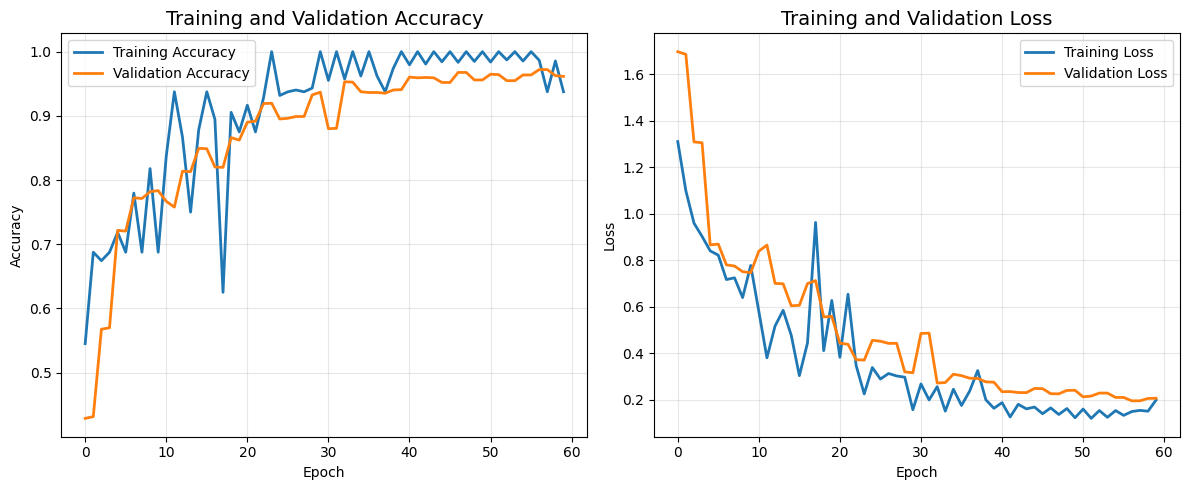

In [82]:
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_mobilenetv1.png', dpi=300)
plt.show()

# Cek Output Model

In [83]:
print("\n" + "="*50)
print("INFORMASI MODEL")
print("="*50)
print("Number of classes in test_generator:", test_generator.num_classes)
print("Number of classes in model output:", model.output_shape)


INFORMASI MODEL
Number of classes in test_generator: 4
Number of classes in model output: (None, 4)


# Load Model Terbaik

In [84]:
model.load_weights('best_model_mobilenetv1.h5')
print("✅ Model terbaik dimuat dari: best_model_mobilenetv2.h5")

✅ Model terbaik dimuat dari: best_model_mobilenetv2.h5


# EVALUASI MODEL PADA DATA TEST

In [85]:
print("\n" + "="*50)
print("EVALUASI MODEL PADA DATA TEST")
print("="*50)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")



EVALUASI MODEL PADA DATA TEST
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.9818 - loss: 0.1625
Test accuracy: 0.9717
Test Loss: 0.1956


# PREDIKSI PADA DATA TEST

In [86]:
# Prediksi
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Ambil label sebenarnya
y_true = test_generator.classes


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step


# CLASSIFICATION REPORT

In [87]:
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=list(test_generator.class_indices.keys())
))


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    MildDemented       0.99      0.98      0.99       300
ModerateDemented       1.00      1.00      1.00       300
     NonDemented       0.95      0.95      0.95       300
VeryMildDemented       0.95      0.95      0.95       300

        accuracy                           0.97      1200
       macro avg       0.97      0.97      0.97      1200
    weighted avg       0.97      0.97      0.97      1200



# CONFUSION MATRIX

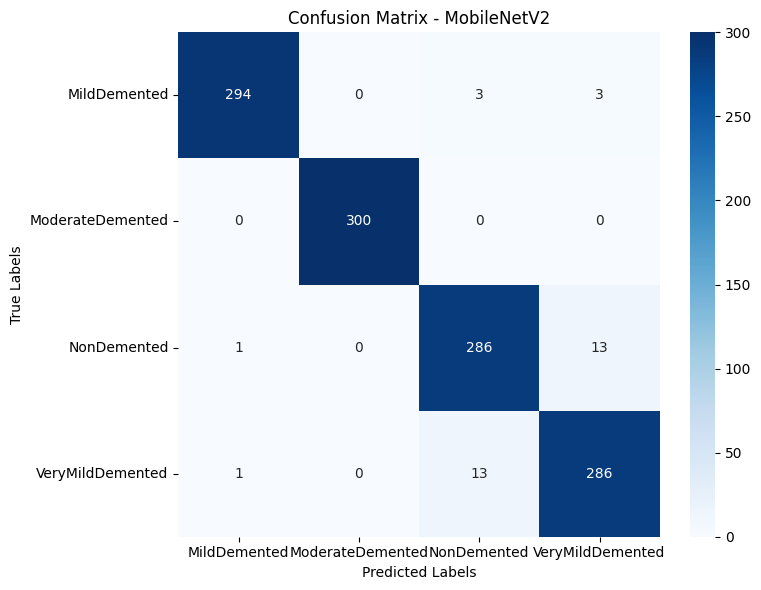

In [88]:
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - MobileNetV2')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# SIMPAN MODEL FINAL

In [89]:
print("\n" + "="*50)
print("MENYIMPAN MODEL")
print("="*50)

# Simpan model final
model.save('mobilenetv1_tb_final.h5')
print("✅ Model final disimpan: mobilenetv2_tb_final.h5")


MENYIMPAN MODEL
✅ Model final disimpan: mobilenetv2_tb_final.h5


# RINGKASAN HASIL

In [90]:
print("\n" + "="*60)
print("🎉 RINGKASAN HASIL TRAINING MOBILENETV2 🎉")
print("="*60)

print(f"""
📊 HASIL EVALUASI:
   Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)
   Test Loss     : {test_loss:.4f}

📁 FILE YANG TERSIMPAN:
   1. best_model_mobilenetv2.h5   (model terbaik dari training)
   2. mobilenetv2_tb_final.h5     (model final)
   3. training_history.png         (grafik training)
   4. confusion_matrix.png         (matriks confusion)
""")

print("="*60)
print("✅ TRAINING MOBILENETV2 SELESAI!")
print("="*60)


🎉 RINGKASAN HASIL TRAINING MOBILENETV2 🎉

📊 HASIL EVALUASI:
   Test Accuracy : 0.9717 (97.17%)
   Test Loss     : 0.1956

📁 FILE YANG TERSIMPAN:
   1. best_model_mobilenetv2.h5   (model terbaik dari training)
   2. mobilenetv2_tb_final.h5     (model final)
   3. training_history.png         (grafik training)
   4. confusion_matrix.png         (matriks confusion)

✅ TRAINING MOBILENETV2 SELESAI!
